Part A: Understanding the Dataset
Q1. Dataset Overview Load the dataset and answer the following:


Saving agriculture_yield_dataset.csv to agriculture_yield_dataset (8).csv
(i) How many rows and columns are present?
Number of rows: 1500
Number of columns: 8
(ii) What are the names of all columns?
Column names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']
(iii) Display the first 10 records.
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4     

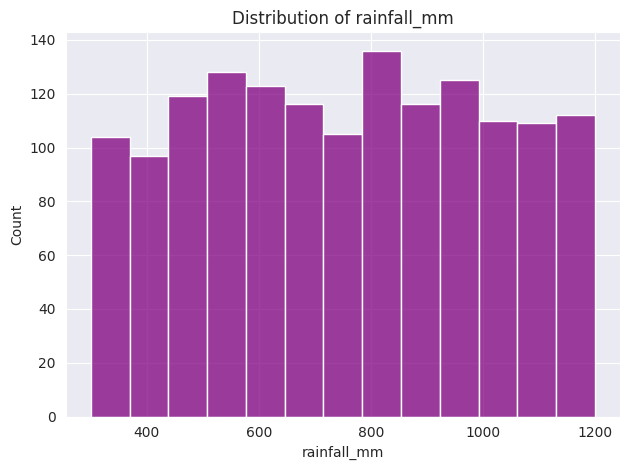

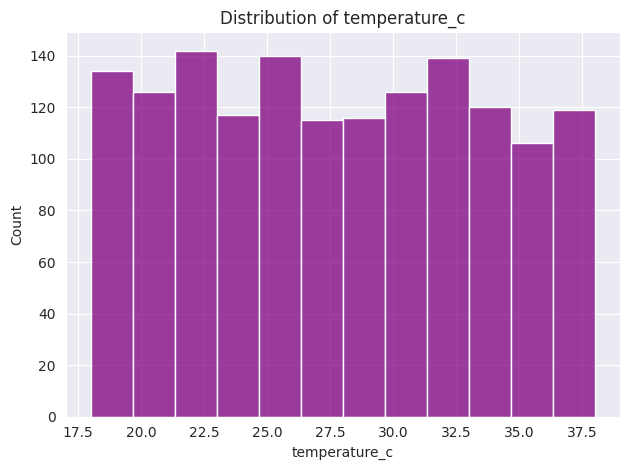

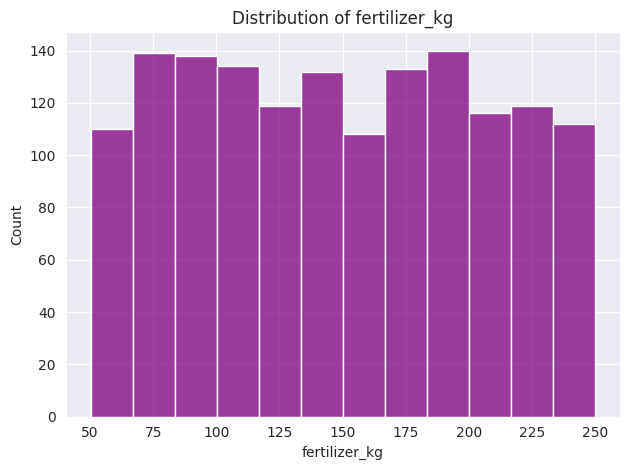

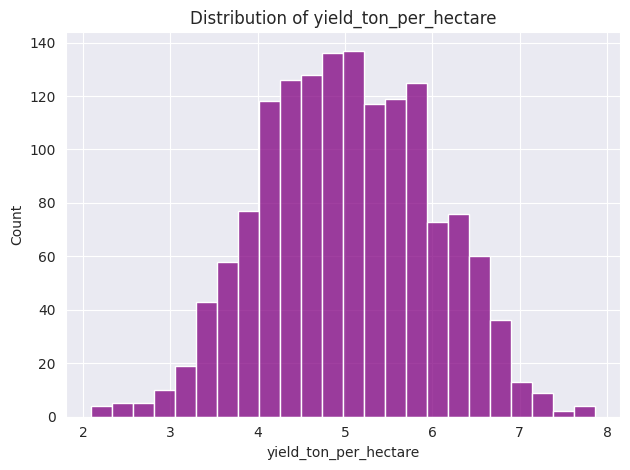

Q5. Crop Type Analysis
(i) Find the number of records for each crop type.
crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64
(ii) Create a count plot (bar chart) for crop_type.


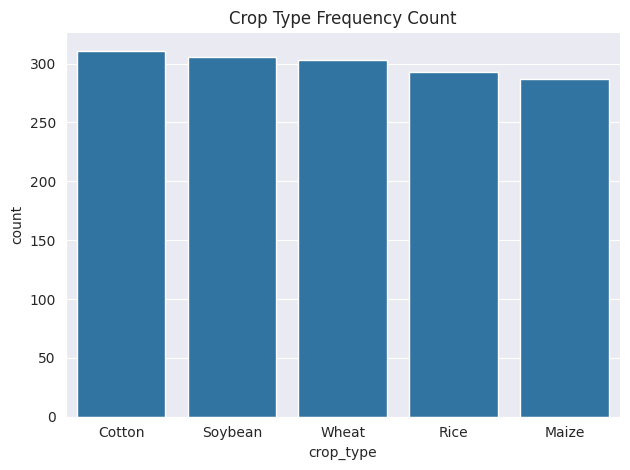

(iii) Which crop appears most frequently?
Most frequent crop: 'Cotton'
Q7. Yield Distribution
(i) Create a histogram of yield_ton_per_hectare.


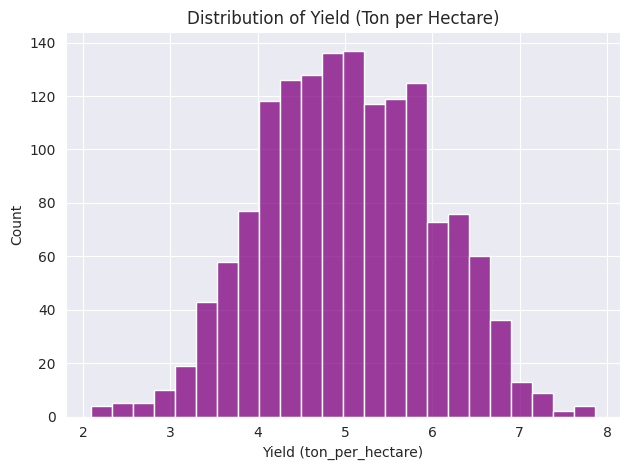

(ii) Is the distribution approximately normal?
Mean: 5.028793333333333
Median: 5.01
Skewness: -0.001169711222739871
The distribution is approximately normal.
(iii) Are there any noticeable outliers?
IQR Bounds for Outliers: Lower = 2.23, Upper = 7.84
Number of statistical outliers found: 3
Q8. Scatter Plot Analysis
(i) Create scatter plots of: 1. rainfall_mm vs yield_ton_per_hectare  2. fertilizer_kg vs yield_ton_per_hectare


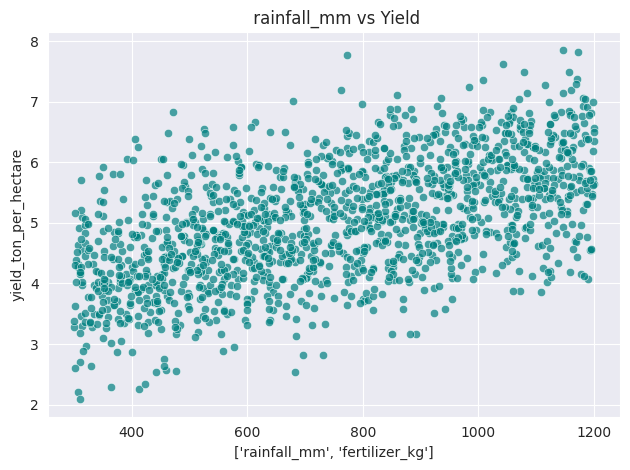

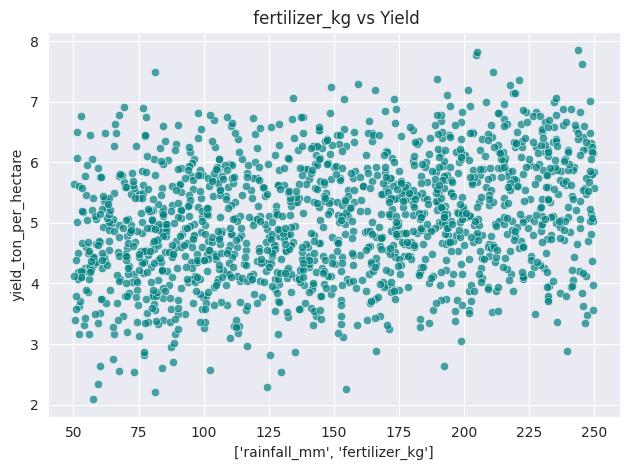

(ii) Which feature appears to have a stronger relationship with yield? 
CORRELATION STATISTICS
The feature with the strongest relationship to crop yield is 'rainfall_mm' with a correlation coefficient of 0.5537.
(i) Generate a correlation matrix for numerical features.
                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg               

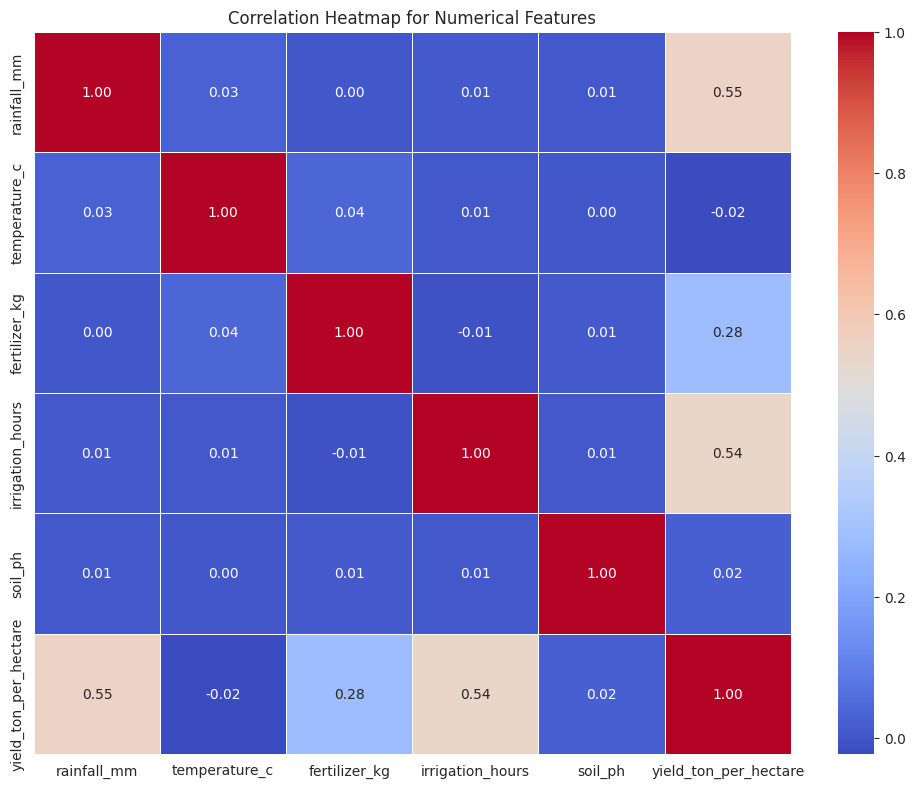

(iii) Identify the top three features most correlated with crop yield.
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64
Q10. Group-Based Analysis
(i) Calculate the average yield for: Each crop type, Each soil type

Q10. Average Yield for each Crop Type:
crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Q10. Average Yield for each Soil Type:
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64
(ii) Which crop and soil type have the highest average yield?
Crop with highest average yield: 'Rice' (5.49)
Soil type with highest average yield: 'Loamy' (5.37)
Part C: Data Preparation
Q11. Feature Encoding The dataset contains categorical variables. Identify the categorical columns. & Convert them into numerical form using One-Hot Encoding. Display the firs

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

print("Part A: Understanding the Dataset")
print("Q1. Dataset Overview Load the dataset and answer the following:")
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("agriculture_yield_dataset.csv")
print("(i) How many rows and columns are present?")
rows, cols = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")
print("(ii) What are the names of all columns?")
print("Column names:")
print(list(df.columns))
print("(iii) Display the first 10 records.")
print(df.head(10))
print("Q2. Data Types and Missing Values")
print("(i) Check the data type of each column." )
print(df.dtypes)
print ("(ii) Identify whether any missing values are present. ")
missing_values = df.isnull().sum()
if missing_values.sum() > 0:
    print("There are missing values")
else:
    print("No missing values detected.")
print("\n")
print("(iii) If missing values exist, mention the affected columns.")
missing_values = df.isnull().sum()
if missing_values.sum() > 0:
    affected_cols = missing_values[missing_values > 0].index.tolist()
    print(f"Affected columns: {affected_cols}")
else:
    print("No missing values detected.")
print("Q3. Descriptive Statistics: Generate summary statistics for all numerical features and answer:")
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
statsum = df[numerical_cols].describe()
print(statsum)
print("(i) Which feature has the highest mean value? ")
mean = df[numerical_cols].mean()
print("Feature with highest mean value is", {mean.idxmax()})
print("(ii) Which feature has the highest standard deviation?")
std = df[numerical_cols].std()
print("Feature with highest standard deviation is", {std.idxmax()})
print("Part B: Exploratory Data Analysis (EDA) ")
print("Q4. Distribution Analysis ")
features = ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'yield_ton_per_hectare']
for i in features:
    plt.figure()
    sns.histplot(data=df, x=i, color='purple')
    plt.title(f'Distribution of {i}')
    plt.xlabel(i)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
print("Q5. Crop Type Analysis")
print("(i) Find the number of records for each crop type.")
crop_counts = df['crop_type'].value_counts()
print(crop_counts)
print("(ii) Create a count plot (bar chart) for crop_type.")
plt.figure()
sns.countplot(data=df, x='crop_type', order=crop_counts.index)
plt.title('Crop Type Frequency Count')
plt.tight_layout()
plt.show()
print("(iii) Which crop appears most frequently?")
print(f"Most frequent crop: '{crop_counts.idxmax()}'")
print("Q7. Yield Distribution")
print("(i) Create a histogram of yield_ton_per_hectare.")
yield_data = df['yield_ton_per_hectare']
sns.set_style('darkgrid')
plt.figure()
sns.histplot(data=df, x='yield_ton_per_hectare', color='purple')
plt.title('Distribution of Yield (Ton per Hectare)')
plt.xlabel('Yield (ton_per_hectare)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print("(ii) Is the distribution approximately normal?")
mean = yield_data.mean()
median = yield_data.median()
skewness = yield_data.skew()
print("Mean:", mean)
print("Median:" , median)
print("Skewness:", skewness)
if abs(skewness) < 0.5:
    print("The distribution is approximately normal.")
else:
    print("The distribution is not normal.")
print("(iii) Are there any noticeable outliers?")
Q1 = yield_data.quantile(0.25)
Q3 = yield_data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(yield_data < lower_bound) | (yield_data > upper_bound)]
print(f"IQR Bounds for Outliers: Lower = {lower_bound:.2f}, Upper = {upper_bound:.2f}")
print(f"Number of statistical outliers found: {len(outliers)}")
print("Q8. Scatter Plot Analysis")
print("(i) Create scatter plots of: 1. rainfall_mm vs yield_ton_per_hectare  2. fertilizer_kg vs yield_ton_per_hectare")
x = ['rainfall_mm', 'fertilizer_kg']
y = 'yield_ton_per_hectare'
for i in x:
    plt.figure()
    sns.scatterplot(data=df, x=i, y=y, alpha=0.7, color='teal')
    plt.title(f' {i} vs Yield')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.tight_layout()
    plt.show()
print("(ii) Which feature appears to have a stronger relationship with yield? ")
correlation_matrix = df.select_dtypes(include=['number']).corr()
yield_correlations = correlation_matrix['yield_ton_per_hectare'].drop('yield_ton_per_hectare')
print("CORRELATION STATISTICS")
for i, value in yield_correlations.items():
  strongest_feature = yield_correlations.abs().idxmax()
  strongest_value = yield_correlations[strongest_feature]
print(f"The feature with the strongest relationship to crop yield is '{strongest_feature}' "
      f"with a correlation coefficient of {strongest_value:.4f}.")
("Q9. Correlation Analysis")
print("(i) Generate a correlation matrix for numerical features.")
corr_matrix = df[numerical_cols].corr()
print(corr_matrix)
print("(ii) Create a heatmap.")
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap for Numerical Features')
plt.tight_layout()
plt.show()
print("(iii) Identify the top three features most correlated with crop yield.")
top_corr = corr_matrix['yield_ton_per_hectare'].drop('yield_ton_per_hectare').abs().sort_values(ascending=False)
print(top_corr.head(3))
print("Q10. Group-Based Analysis")
print("(i) Calculate the average yield for: Each crop type, Each soil type")
avg_yield_crop = df.groupby('crop_type')['yield_ton_per_hectare'].mean()
avg_yield_soil = df.groupby('soil_type')['yield_ton_per_hectare'].mean()
print("\nQ10. Average Yield for each Crop Type:")
print(avg_yield_crop)
print("\nQ10. Average Yield for each Soil Type:")
print(avg_yield_soil)
print("(ii) Which crop and soil type have the highest average yield?")
print(f"Crop with highest average yield: '{avg_yield_crop.idxmax()}' ({avg_yield_crop.max():.2f})")
print(f"Soil type with highest average yield: '{avg_yield_soil.idxmax()}' ({avg_yield_soil.max():.2f})")
print("Part C: Data Preparation")
print("Q11. Feature Encoding The dataset contains categorical variables. Identify the categorical columns. & Convert them into numerical form using One-Hot Encoding. Display the first five rows of the transformed dataset")
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)
for col in df_encoded.columns:
    if df_encoded[col].dtype == bool:
        df_encoded[col] = df_encoded[col].astype(int)
print(df_encoded.head(5))
print("Q12. Feature Selection Separate:  Input features (X)   Target variable (y)  Specify which column is being used as the target variable.")
y = 'yield_ton_per_hectare'
X = df_encoded.drop(columns=[y])
y = df_encoded[y]
print(f"\n Target variable: '{y}'")
print("Part D: Machine Learning")
print("Q13. Train-Test Split Split the dataset into: 80% Training Data, 20% Testing Data. Display the shape of:  X_train, X_test, y_train, y_test")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print("Q14. Linear Regression Model: Train a Linear Regression model. Display the model coefficients and intercept. Which feature has the highest positive coefficient?")
model = LinearRegression()
model.fit(X_train, y_train)
print(f"Model Intercept: {model.intercept_:.6f}")
coefficients_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print("\nModel Coefficients:")
print(coefficients_df.to_string(index=False))
highest_pos_coef = coefficients_df.loc[coefficients_df['Coefficient'].idxmax()]
print(f"\nFeature with the highest positive coefficient: '{highest_pos_coef['Feature']}' ({highest_pos_coef['Coefficient']:.6f})")